### Debugging and Monitoring

In [34]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langchain.chat_models import init_chat_model

import os
from dotenv import load_dotenv

load_dotenv()


True

In [35]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="agentic-langgraph"

In [36]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [37]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")

@tool
def multiply(a:int, b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b
tool_node = ToolNode([multiply])


In [38]:
llm_with_tools = llm.bind_tools([multiply])

In [39]:
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [40]:
builder = StateGraph(State)

builder

In [41]:
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", tool_node)

In [42]:
from langgraph.prebuilt import tools_condition
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)


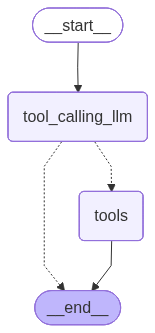

In [43]:
from IPython.display import display, Image

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
response = graph.invoke({"messages":"What is the machine learning"})
print(response["messages"][-1].content)

Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, identifies patterns, and makes decisions or predictions based on that data.

There are several types of machine learning, including:

1. **Supervised learning**: The machine is trained on labeled data, where the correct output is already known. The goal is to learn a mapping between input data and the corresponding output labels.
2. **Unsupervised learning**: The machine is trained on unlabeled data, and the goal is to discover patterns, relationships, or groupings in the data.
3. **Reinforcement learning**: The machine learns by interacting with an environment and receiving rewards or penalties for its actions. The goal is to learn a policy that maximizes the cumulative reward.

Machine learning has many applications, including:

1. **Image recogn

In [48]:
response = graph.invoke({
    "messages": [{"role": "user", "content": "Multiply 5 and 7"}]
})

print(response)

{'messages': [HumanMessage(content='Multiply 5 and 7', additional_kwargs={}, response_metadata={}, id='cf3b217a-b160-49a2-8769-e1cfeaf119c1'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'td7dk98jd', 'function': {'arguments': '{"a":5,"b":7}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 276, 'total_tokens': 295, 'completion_time': 0.066646677, 'completion_tokens_details': None, 'prompt_time': 0.187581527, 'prompt_tokens_details': None, 'queue_time': 0.069000992, 'total_time': 0.254228204}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c9f6a-6131-79d2-b504-2fe19e34df70-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 7}, 'id': 'td7dk98jd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 276, 'output_tok